In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay
)

from config import (
    TARGET_COLUMN,
    METRICS_DIR
)

from src.data.data_loader import load_supervised_features

from src.eda.eda_utils import (
    get_dataframe_overview,
    get_target_summary
)

from src.models.supervised_models import SupervisedModelTrainer
from src.models.model_interpretation import SupervisedModelInterpreter
from src.models.threshold_tuning import ThresholdTuner

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

The scope of this notebook is to train and evaluate binary classification models for default-risk prediction.

Supervised modeling workflow uses the processed features created during preprocessing and future engineering steps.

The modeling approach in this notebook is:
* Use logistic regression as the baseline model
* Compare the baseline against benchmark non-linear models
* Evaluate models using metrics suitable for imbalanced binary classification
* Interpret the results from both statistical and credit-risk business prespectives

Main evaluation metrics are considered as PR-AUC, ROC-AUC, recall, precsion, f1-score, and balanced accuracy due to imbalanced minority class data structure.

#### **Supervised Features**

In [2]:
### loading features
# supervised features
supervised_features = load_supervised_features()
print(f'Supervised features shape: {supervised_features.shape}')
supervised_features.head()

Supervised features shape: (59472, 43)


,Loan To Value,Branch ID,Age,Employment Type,State,FICO Score,Number of Accounts,Number of Active Accounts,Number of Overdue Accounts,Current Balance Amount,Disbursed Amount,Instalment Amount,Number of Accounts Opened Last 6 Months,Average Account Age,Number of Inquiries,Target,DisbursementYear,DisbursementQuarter,DisbursementMonth,DaysSinceDisbursement,IsBureauExcluded,Legit FICO Scores,FICO Rating,FICO Rating Ordinal,HasNegativeCurrentBalance,HasZeroCurrentBalance,CurrentBalancePositiveAmount,InstalmentToDisbursedRatio,BalanceToDisbursedRatio,HasNoActiveAccounts,ActiveAccountRatio,OverdueAccountRatio,RecentlyOpenedAccountRatio,CreditHistoryAgeBand,AccountsPerCreditHistoryMonth,RecentlyOpenedAccountsPerCreditHistoryMonth,InquiryIntensityBand,InquiryPerCreditHistoryMonth,InquiryToAccountRatio,IsHighLTV,IsVeryHighLTV,Legit LTV,InstalmentToDisbursedAmount
0,88.17,18,53,Self employed,Louisiana,681,9,3.0,0,63727,100984,5571,1,9,0,0,2018,3,8,0,0,681.0,Good,3,0,0,1,0.055167,0.000010,0,0.333333,0.000000,0.111111,Young,1.000000,0.111111,No Inquiry,0.0,0.0,1,0,88.17,0.055167
1,83.78,13,39,Salaried,Tennessee,384,3,1.0,1,103435,100000,160963,0,36,0,1,2018,3,8,0,0,384.0,Poor,1,0,0,1,1.609630,0.000010,0,0.333333,0.333333,0.000000,Mature,0.083333,0.000000,No Inquiry,0.0,0.0,1,0,83.78,1.609630
2,74.89,63,28,Salaried,New Jersey,673,8,2.0,0,120985,130600,15820,1,1,0,0,2018,3,8,0,0,673.0,Good,3,0,0,1,0.121133,0.000008,0,0.250000,0.000000,0.125000,Very Young,8.000000,1.000000,No Inquiry,0.0,0.0,0,0,74.89,0.121133
3,73.65,67,35,Self employed,Nevada,16,1,0.0,0,0,0,0,0,6,0,0,2018,3,8,0,1,NaN,Bureau Excluded,0,0,1,1,NaN,NaN,1,0.000000,0.000000,0.000000,Young,0.166667,0.000000,No Inquiry,0.0,0.0,0,0,73.65,NaN
4,83.29,16,32,Salaried,Illinois,626,6,2.0,0,42588,51320,7916,3,4,0,0,2018,3,8,0,0,626.0,Fair,2,0,0,1,0.154248,0.000019,0,0.333333,0.000000,0.500000,Very Young,1.500000,0.750000,No Inquiry,0.0,0.0,1,0,83.29,0.154248


In [3]:
### supervised features - dataframe overview
overview = get_dataframe_overview(df = supervised_features)
overview

,dtype,missing_count,missing_rate,unique_count,unique_rate
InstalmentToDisbursedRatio,float64,11120,0.1870,29617,0.4980
InstalmentToDisbursedAmount,float64,11120,0.1870,29617,0.4980
BalanceToDisbursedRatio,float64,11120,0.1870,26575,0.4468
Legit FICO Scores,float64,6522,0.1097,561,0.0094
AccountsPerCreditHistoryMonth,float64,1809,0.0304,1114,0.0187
InquiryPerCreditHistoryMonth,float64,1809,0.0304,257,0.0043
RecentlyOpenedAccountsPerCreditHistoryMonth,float64,1809,0.0304,243,0.0041
ActiveAccountRatio,float64,222,0.0037,415,0.0070
Number of Active Accounts,float64,222,0.0037,36,0.0006
Legit LTV,float64,34,0.0006,5346,0.0899


In [4]:
### supervised features - target distribution
target_summary = get_target_summary(
    df = supervised_features,
    target_column = TARGET_COLUMN
)
target_summary

,count,ratio,percentage
Target,,,
0,50477,0.848752,84.875235
1,8995,0.151248,15.124765


#### **Modelling**

The model training workflow uses the SupervisedModelTrainer class. The trainer applier the same model preprocessing pipeline to each candidate baseline and benchmark classifiers, which
ensures that models are compared under a consistent preprocessing setup.

Preprocessing pipeline steps:
* numeric imputation
* robust scaling
* outlier handling
* one-hot encoding for low-cardinality categorical variables
* target encoding for high-cardinality categorical variables

Candidate models:
* Logistic Regression -> baseline
* Decision Tree
* Random Forest
* Gradient Boosting

Class imbalance is handled using stratified train-test split, class weights, and balanced sample weights for Gradient Boosting case. 

In [5]:
### supervised model - initialize trainer
trainer = SupervisedModelTrainer(
    target_column = TARGET_COLUMN,
    test_size = 0.2,
    random_state = 2,
    threshold = 0.5
)

# candidate models
candidate_models = trainer.get_candidate_models()
candidate_models

{'logistic_regression_baseline': LogisticRegression(C=0.01, class_weight='balanced', max_iter=5000,
                    random_state=2, tol=0.001),
 'decision_tree_depth4': DecisionTreeClassifier(class_weight='balanced', max_depth=4,
                        min_samples_leaf=100, random_state=2),
 'random_forest_light': RandomForestClassifier(class_weight='balanced_subsample', max_depth=8,
                        min_samples_leaf=50, n_estimators=300, n_jobs=-1,
                        random_state=2),
 'gradient_boosting_light': GradientBoostingClassifier(learning_rate=0.05, n_estimators=150, random_state=2)}

In [6]:
### supervised model - train candidate models using the model pipeline
classification_metrics = trainer.train_all_models(
    save_models = True,
    save_metrics = True
)
classification_metrics

Training logistic_regression_baseline
Training decision_tree_depth4
Training random_forest_light
Training gradient_boosting_light


,model,threshold,accuracy,balanced_accuracy,precision,recall,f1_score,roc_auc,pr_auc,true_positive,true_negative,false_positive,false_negative,predicted_positive_rate,confusion_matrix,classification_report
0,gradient_boosting_light,0.5,0.787978,0.805435,0.402587,0.830461,0.542287,0.879622,0.582389,1494,7879,2217,305,0.311980,"[[7879, 2217], [305, 1494]]",precision recall f1-score support\n\n 0 0.96 0.78 0.86 10096\n 1 0.40 0.83 0.54 1799\n\n accuracy 0.79 11895\n macro avg 0.68 0.81 0.70 11895\nweighted avg 0.88 0.79 0.81 11895\n
1,random_forest_light,0.5,0.793863,0.804333,0.409331,0.819344,0.545926,0.878701,0.576248,1474,7969,2127,325,0.302732,"[[7969, 2127], [325, 1474]]",precision recall f1-score support\n\n 0 0.96 0.79 0.87 10096\n 1 0.41 0.82 0.55 1799\n\n accuracy 0.79 11895\n macro avg 0.69 0.80 0.71 11895\nweighted avg 0.88 0.79 0.82 11895\n
2,logistic_regression_baseline,0.5,0.770828,0.772491,0.375236,0.774875,0.505622,0.837203,0.495532,1394,7775,2321,405,0.312316,"[[7775, 2321], [405, 1394]]",precision recall f1-score support\n\n 0 0.95 0.77 0.85 10096\n 1 0.38 0.77 0.51 1799\n\n accuracy 0.77 11895\n macro avg 0.66 0.77 0.68 11895\nweighted avg 0.86 0.77 0.80 11895\n
3,decision_tree_depth4,0.5,0.730307,0.787906,0.344858,0.870484,0.494006,0.853581,0.470244,1566,7121,2975,233,0.381757,"[[7121, 2975], [233, 1566]]",precision recall f1-score support\n\n 0 0.97 0.71 0.82 10096\n 1 0.34 0.87 0.49 1799\n\n accuracy 0.73 11895\n macro avg 0.66 0.79 0.66 11895\nweighted avg 0.87 0.73 0.77 11895\n


* we tried to increase the regularization strength and setting a marginal tolerance level due to non-converging structure of baseline model (Logistic Regression) 

In [7]:
### supervised model - display csv-friendly classification metrics excluding confusion matrix and classification report
metrics_csv_friendly = (
    SupervisedModelTrainer
    .make_classification_metrics_csv_safe(
        metrics_df = classification_metrics
    )
)

metrics_csv_friendly

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1_score,roc_auc,pr_auc,true_positive,true_negative,false_positive,false_negative,predicted_positive_rate
0,gradient_boosting_light,0.5,0.787978,0.805435,0.402587,0.830461,0.542287,0.879622,0.582389,1494,7879,2217,305,0.311980
1,random_forest_light,0.5,0.793863,0.804333,0.409331,0.819344,0.545926,0.878701,0.576248,1474,7969,2127,325,0.302732
2,logistic_regression_baseline,0.5,0.770828,0.772491,0.375236,0.774875,0.505622,0.837203,0.495532,1394,7775,2321,405,0.312316
3,decision_tree_depth4,0.5,0.730307,0.787906,0.344858,0.870484,0.494006,0.853581,0.470244,1566,7121,2975,233,0.381757


* the classification metric results are sorted by PR-AUC, since we need to focus on the model's ability to identift positive/default cases while accounting for the precision-recall tradeoff

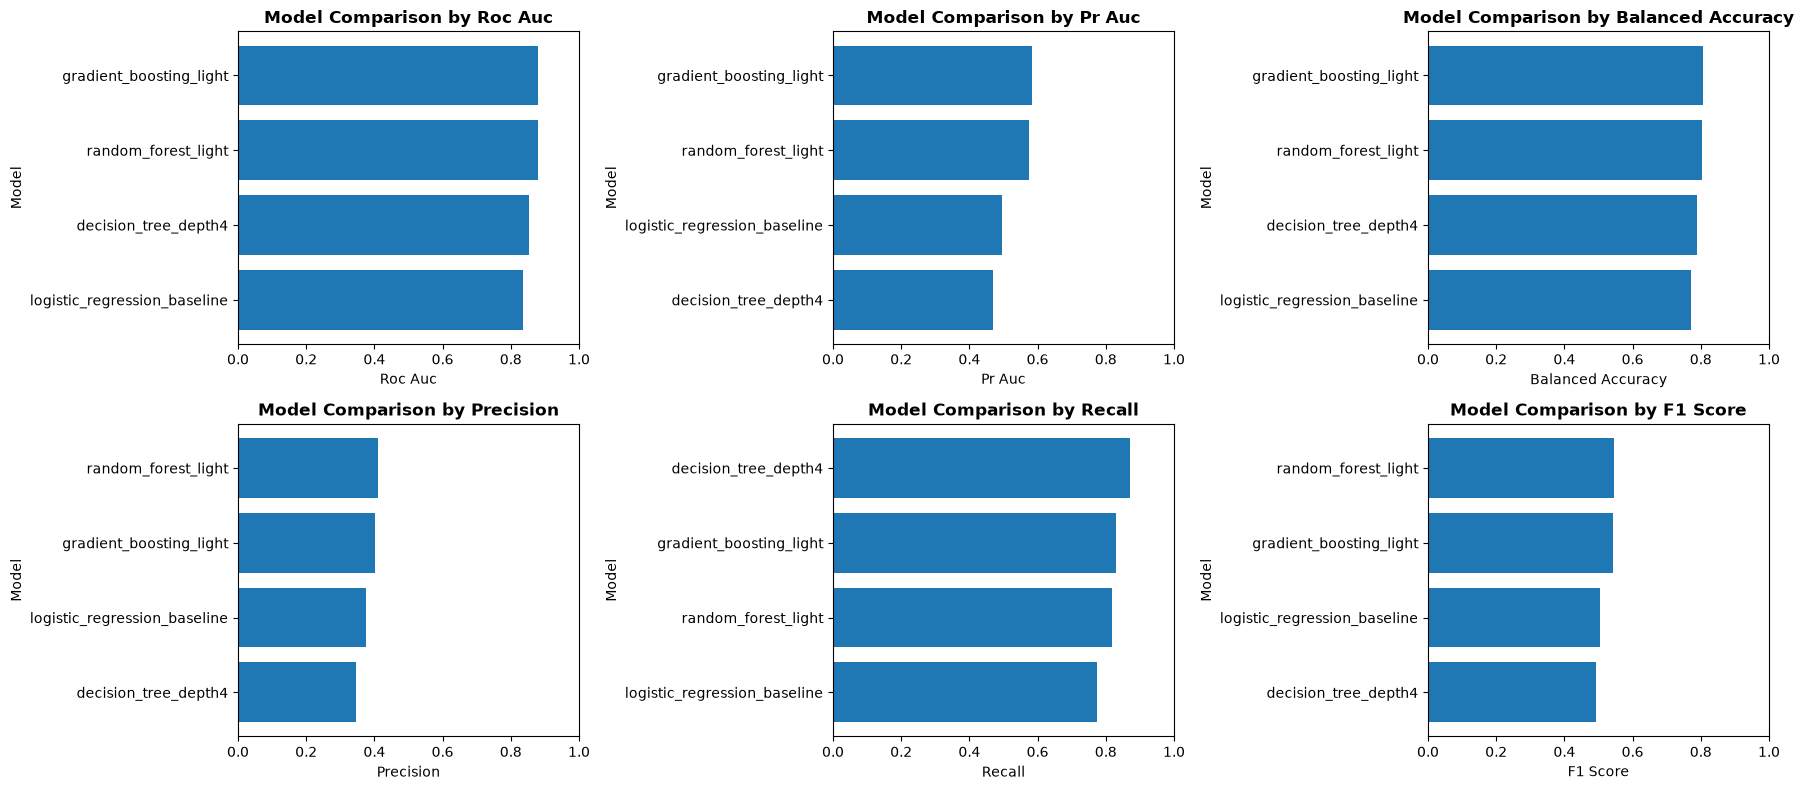

In [8]:
### supervised model - model comparison bar plots
metric_columns = [
    'roc_auc',
    'pr_auc',
    'balanced_accuracy',
    'precision',
    'recall',
    'f1_score'
]

fig, axes = plt.subplots(
    nrows = 2,
    ncols = 3,
    figsize = (18, 8)
)

axes = axes.flatten()

for ax, metric in zip(axes, metric_columns):

    plot_df = metrics_csv_friendly.sort_values(
        by = metric,
        ascending = True
    )

    ax.barh(
        plot_df['model'],
        plot_df[metric]
    )

    metric_label = metric.replace("_", " ").title()

    ax.set_title(
        f'Model Comparison by {metric_label}',
        fontweight = 'bold'
    )

    ax.set_xlabel(metric_label)
    ax.set_ylabel('Model')
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

In [9]:
classification_metrics

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1_score,roc_auc,pr_auc,true_positive,true_negative,false_positive,false_negative,predicted_positive_rate,confusion_matrix,classification_report
0,gradient_boosting_light,0.5,0.787978,0.805435,0.402587,0.830461,0.542287,0.879622,0.582389,1494,7879,2217,305,0.311980,"[[7879, 2217], [305, 1494]]",precision recall f1-score support\n\n 0 0.96 0.78 0.86 10096\n 1 0.40 0.83 0.54 1799\n\n accuracy 0.79 11895\n macro avg 0.68 0.81 0.70 11895\nweighted avg 0.88 0.79 0.81 11895\n
1,random_forest_light,0.5,0.793863,0.804333,0.409331,0.819344,0.545926,0.878701,0.576248,1474,7969,2127,325,0.302732,"[[7969, 2127], [325, 1474]]",precision recall f1-score support\n\n 0 0.96 0.79 0.87 10096\n 1 0.41 0.82 0.55 1799\n\n accuracy 0.79 11895\n macro avg 0.69 0.80 0.71 11895\nweighted avg 0.88 0.79 0.82 11895\n
2,logistic_regression_baseline,0.5,0.770828,0.772491,0.375236,0.774875,0.505622,0.837203,0.495532,1394,7775,2321,405,0.312316,"[[7775, 2321], [405, 1394]]",precision recall f1-score support\n\n 0 0.95 0.77 0.85 10096\n 1 0.38 0.77 0.51 1799\n\n accuracy 0.77 11895\n macro avg 0.66 0.77 0.68 11895\nweighted avg 0.86 0.77 0.80 11895\n
3,decision_tree_depth4,0.5,0.730307,0.787906,0.344858,0.870484,0.494006,0.853581,0.470244,1566,7121,2975,233,0.381757,"[[7121, 2975], [233, 1566]]",precision recall f1-score support\n\n 0 0.97 0.71 0.82 10096\n 1 0.34 0.87 0.49 1799\n\n accuracy 0.73 11895\n macro avg 0.66 0.79 0.66 11895\nweighted avg 0.87 0.73 0.77 11895\n


In [10]:
### supervised model - classification reports for baseline & benchmark models
for model_name in classification_metrics['model']:
    print(model_name)
    print(
        trainer
        .get_classification_report(model_name = model_name)
    )
    print()

gradient_boosting_light
              precision    recall  f1-score   support

           0       0.96      0.78      0.86     10096
           1       0.40      0.83      0.54      1799

    accuracy                           0.79     11895
   macro avg       0.68      0.81      0.70     11895
weighted avg       0.88      0.79      0.81     11895


random_forest_light
              precision    recall  f1-score   support

           0       0.96      0.79      0.87     10096
           1       0.41      0.82      0.55      1799

    accuracy                           0.79     11895
   macro avg       0.69      0.80      0.71     11895
weighted avg       0.88      0.79      0.82     11895


logistic_regression_baseline
              precision    recall  f1-score   support

           0       0.95      0.77      0.85     10096
           1       0.38      0.77      0.51      1799

    accuracy                           0.77     11895
   macro avg       0.66      0.77      0.68     11895

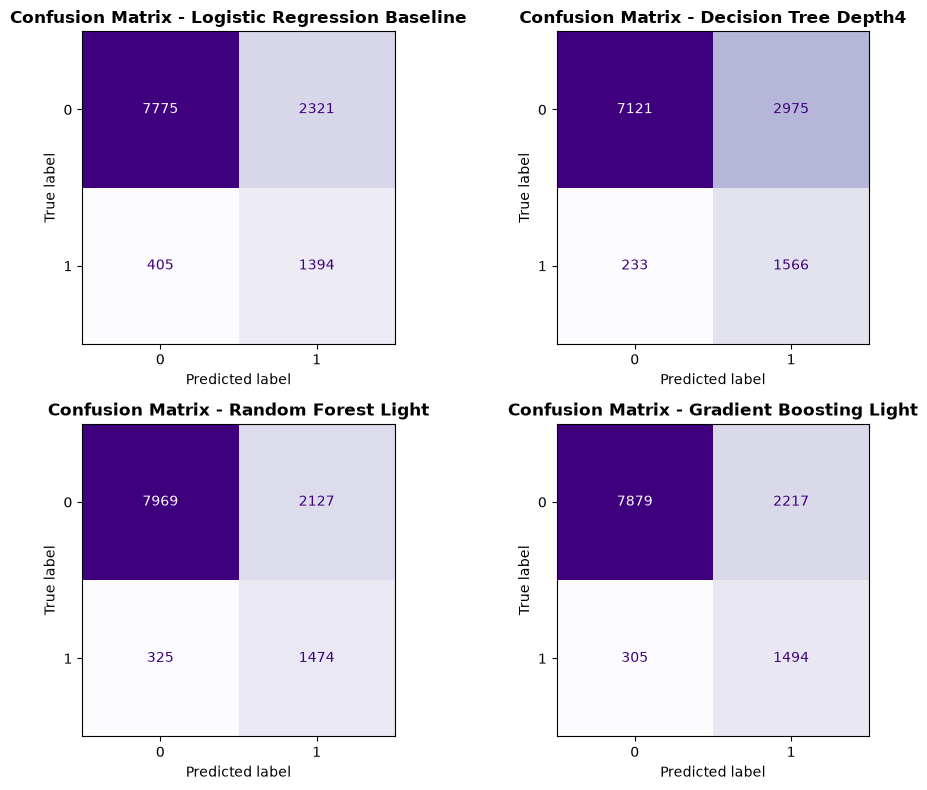

In [11]:
### supervised model - confusion matrices for baseline & benchmark models
if trainer.X_test_ is None:
    raise ValueError('X_test_ is not available, please fit the trainer first!')
if trainer.y_test_ is None:
    raise ValueError('y_test_ is not available, please fit the trainer first!')

n_models = len(trainer.trained_pipelines_)
n_cols = 2
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(
    nrows = n_rows,
    ncols = n_cols,
    figsize = (5 * n_cols, 4 * n_rows),
    squeeze = False
)

axes = axes.flatten()

for ax, (model_name, pipeline) in zip(axes, trainer.trained_pipelines_.items()):

    # get model predictions
    y_probability = pipeline.predict_proba(trainer.X_test_)[:, 1]
    y_prediction = (y_probability >= trainer.threshold).astype(int)

    ConfusionMatrixDisplay.from_predictions(
        y_true = trainer.y_test_,
        y_pred = y_prediction,
        values_format = 'd',
        cmap = 'Purples',
        ax = ax,
        colorbar = False
    )

    model_label = model_name.replace("_", " ").title()

    ax.set_title(
        f'Confusion Matrix - {model_label}',
        fontweight = 'bold'
    )

plt.tight_layout()
plt.show()

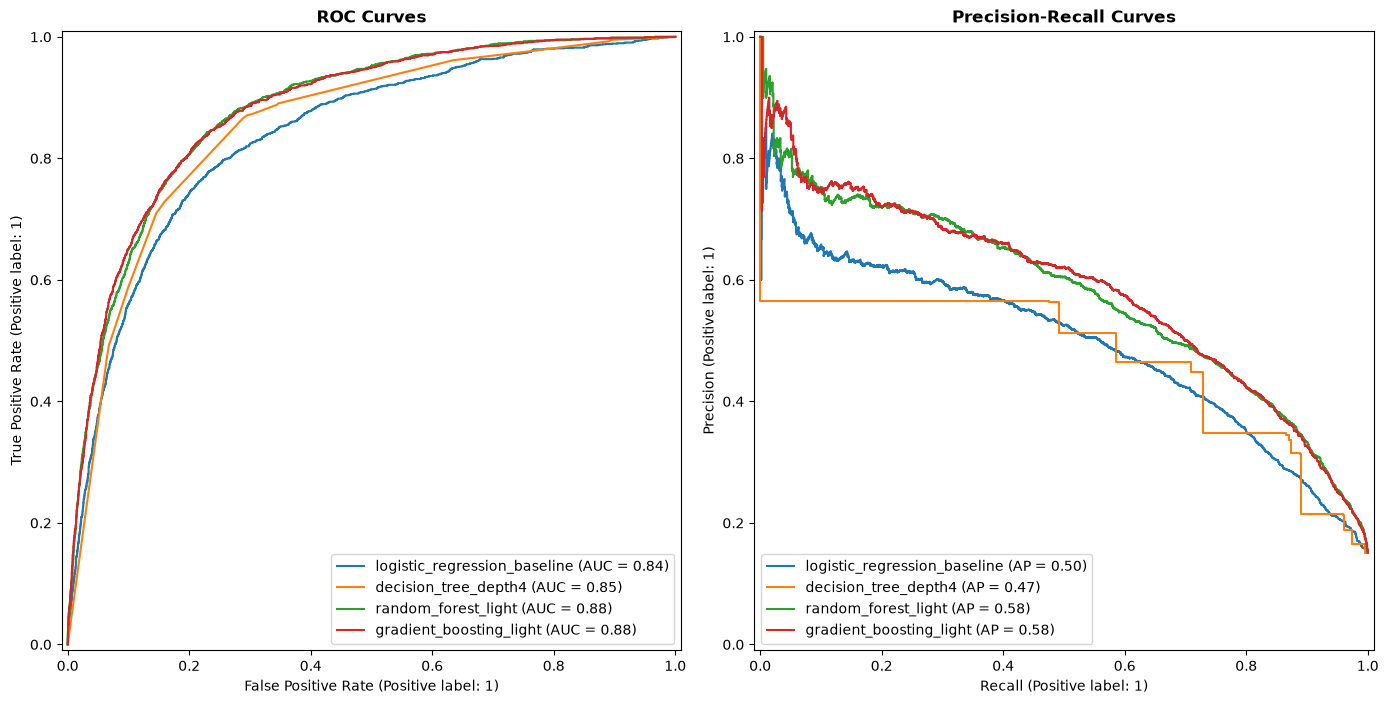

In [12]:
### supervised model - ROC & precision-recall curves for baseline & benchmark models
if trainer.X_test_ is None:
    raise ValueError('X_test_ is not available, please fit the trainer first!')
if trainer.y_test_ is None:
    raise ValueError('y_test_ is not available, please fit the trainer first!')

fig, axes = plt.subplots(
    nrows = 1,
    ncols = 2,
    figsize = (7 * n_cols, 5 * n_rows),
    squeeze = False
)

ax_roc = axes[0, 0]
ax_pr = axes[0, 1]

for model_name, pipeline in trainer.trained_pipelines_.items():

    RocCurveDisplay.from_estimator(
        estimator = pipeline,
        X = trainer.X_test_,
        y = trainer.y_test_,
        name = model_name,
        ax = ax_roc
    )

    PrecisionRecallDisplay.from_estimator(
        estimator = pipeline,
        X = trainer.X_test_,
        y = trainer.y_test_,
        name = model_name,
        ax = ax_pr
    )

ax_roc.set_title(
    'ROC Curves',
    fontweight = 'bold'
)

ax_pr.set_title(
    'Precision-Recall Curves',
    fontweight = 'bold'
)

plt.tight_layout()
plt.show()

In [13]:
### supervised model - threshold sensitivity for the baseline model (Logistic Regression Classifier)
if trainer.X_test_ is None:
    raise ValueError('X_test_ is not available, please fit the trainer first!')
if trainer.y_test_ is None:
    raise ValueError('y_test_ is not available, please fit the trainer first!')

baseline_model_name = 'logistic_regression_baseline'
baseline_pipeline = trainer.trained_pipelines_[baseline_model_name]

y_probability = baseline_pipeline.predict_proba(trainer.X_test_)[:, 1]

thresholds = np.arange(0.25, 0.76, 0.05)

threshold_results = []

for threshold in thresholds:

    # get predictions
    y_prediction = (y_probability >= threshold).astype(int)

    tp = (
        (trainer.y_test_ == 1) & (y_prediction == 1)
    ).sum()

    tn = (
        (trainer.y_test_ == 0) & (y_prediction == 0)
    ).sum()

    fp = (
        (trainer.y_test_ == 0) & (y_prediction == 1)
    ).sum()

    fn = (
        (trainer.y_test_ == 1) & (y_prediction == 0)
    ).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    predicted_positive_rate = y_prediction.mean()

    threshold_results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'predicted_positive_rate': predicted_positive_rate,
        'false_positive': fp,
        'false_negative': fn,
        'true_positive': tp,
        'true_negative': tn
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

,threshold,precision,recall,predicted_positive_rate,false_positive,false_negative,true_positive,true_negative
0,0.25,0.240431,0.918288,0.577638,5219,147,1652,4877
1,0.30,0.272109,0.889383,0.494325,4280,199,1600,5816
2,0.35,0.308869,0.842135,0.412358,3390,284,1515,6706
3,0.40,0.340401,0.812118,0.360824,2831,338,1461,7265
4,0.45,0.359889,0.790995,0.332409,2531,376,1423,7565
5,0.50,0.375236,0.774875,0.312316,2321,405,1394,7775
6,0.55,0.396226,0.747082,0.285162,2048,455,1344,8048
7,0.60,0.422222,0.707615,0.253468,1742,526,1273,8354
8,0.65,0.452298,0.650917,0.217654,1418,628,1171,8678
9,0.70,0.481481,0.592551,0.186129,1148,733,1066,8948


* threshold selection should be linked to business objectives; therefore, the investigation capacity. As we impose a stricter threshold, we can observe the bump in precision, but at the expense of missing true_positives, which might be costly for the business as well as the reputational damage that the bank may face. Likewise, a looser threshold may increase the recall rate significantly, but poses another threat such as customer friction for the business.

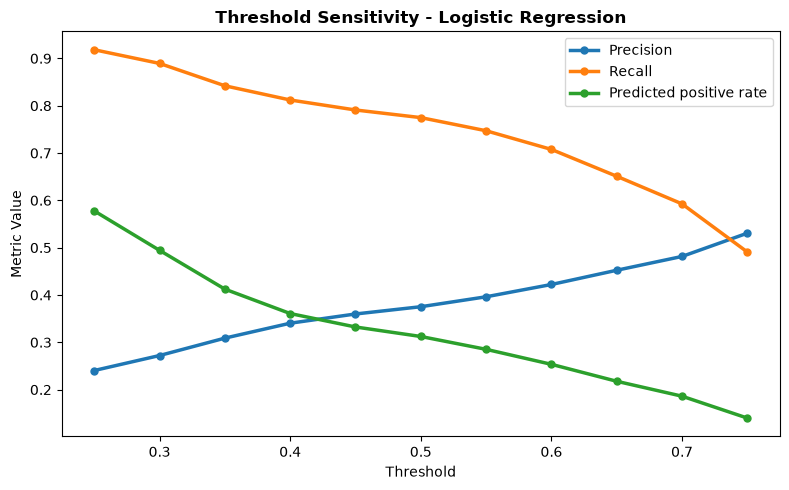

In [14]:
### supervised model - threshold sensitivity plot for the baseline model (Logistic Regression Classifier)
plt.figure(figsize = (8, 5))

plt.plot(
    threshold_results_df['threshold'],
    threshold_results_df['precision'],
    marker = 'o',
    markersize = 5,
    linewidth = 2.5,
    label = 'Precision'
)

plt.plot(
    threshold_results_df['threshold'],
    threshold_results_df['recall'],
    marker = 'o',
    markersize = 5,
    linewidth = 2.5,
    label = 'Recall'
)

plt.plot(
    threshold_results_df['threshold'],
    threshold_results_df['predicted_positive_rate'],
    marker = 'o',
    markersize = 5,
    linewidth = 2.5,
    label = 'Predicted positive rate'
)

plt.title(
    'Threshold Sensitivity - Logistic Regression',
    fontweight = 'bold'
)
plt.xlabel('Threshold')
plt.ylabel('Metric Value')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
### supervised model - save metrics into a notebook summary table
metrics_csv_friendly.to_csv(
    METRICS_DIR / "supervised_model_metrics_notebook_summary.csv",
    index=False
)

threshold_results_df.to_csv(
    METRICS_DIR / "logistic_regression_threshold_sensitivity.csv",
    index=False
)

#### **Model Interpretation**

3 major supervised model interpretation methods are used for binary classifiers in this project

* Logistic regression coefficients
* Native tree-based feature importances
* Permutation importances

For business communication, permutation importance is especially useful, since it reports feature importances at the orıginal feature level. Other model interpretation approaches report the feature importances at the final layer of classifier pipeline methods where the feature names are transformed to sklearn-generated features 

In [16]:
### supervised model - model interpretation - logistic regression coefficients
# initialize model interpreter
interpreter = SupervisedModelInterpreter(
    metrics_dir = METRICS_DIR,
    random_state = 2
)

# logistic regression coefficients
logistic_pipeline = trainer.trained_pipelines_['logistic_regression_baseline']

logistic_coefficients = interpreter.get_logistic_regression_coefficients(
    pipeline = logistic_pipeline,
    model_name = 'logistic_regression_baseline'
)

# add business interpretation
logistic_coefficients_with_notes = interpreter.add_business_interpretation_notes(
    df = logistic_coefficients,
    feature_column = 'feature'
)

display(logistic_coefficients_with_notes.head(15))

# save logistic coefficients
interpreter.save_interpretation_table(
    df = logistic_coefficients_with_notes,
    file_name = 'logistic_regression_coefficients.csv'
)

,model,feature,coefficient,abs_coefficient,odds_ratio,effect_direction,business_interpretation
0,logistic_regression_baseline,low_cardinality_categorical__FICO Rating_Very Good,-0.967124,0.967124,0.380175,decreases_default_risk,Credit bureau quality / creditworthiness signal
1,logistic_regression_baseline,numeric__FICO Rating Ordinal,-0.811660,0.811660,0.444120,decreases_default_risk,Credit bureau quality / creditworthiness signal
2,logistic_regression_baseline,numeric__OverdueAccountRatio,0.741478,0.741478,2.099036,increases_deafult_risk,Historical repayment stress / delinquency signal
3,logistic_regression_baseline,low_cardinality_categorical__FICO Rating_Poor,0.739139,0.739139,2.094132,increases_deafult_risk,Credit bureau quality / creditworthiness signal
4,logistic_regression_baseline,low_cardinality_categorical__FICO Rating_Fair,0.664286,0.664286,1.943103,increases_deafult_risk,Credit bureau quality / creditworthiness signal
5,logistic_regression_baseline,numeric__FICO Score,0.517813,0.517813,1.678353,increases_deafult_risk,Credit bureau quality / creditworthiness signal
6,logistic_regression_baseline,numeric__Number of Overdue Accounts,0.452481,0.452481,1.572208,increases_deafult_risk,Historical repayment stress / delinquency signal
7,logistic_regression_baseline,numeric__HasNoActiveAccounts,-0.429285,0.429285,0.650975,decreases_default_risk,Requires manual business review
8,logistic_regression_baseline,low_cardinality_categorical__FICO Rating_Good,-0.418229,0.418229,0.658211,decreases_default_risk,Credit bureau quality / creditworthiness signal
9,logistic_regression_baseline,numeric__HasZeroCurrentBalance,-0.398421,0.398421,0.671379,decreases_default_risk,Outstanding balance / leverage signal


In [17]:
### supervised model - model interpretation - logistic regression - top positive & negative logistic regression drivers
# positive drivers
top_positive_logistic_drivers = (
    logistic_coefficients_with_notes
    .query('coefficient > 0')
    .sort_values(
        'coefficient',
        ascending = False
    )
    .head(10)
    .reset_index(drop = True)
)

# negative drivers
top_negative_logistic_drivers = (
    logistic_coefficients_with_notes
    .query('coefficient < 0')
    .sort_values(
        'coefficient',
        ascending = True
    )
    .head(10)
    .reset_index(drop = True)
)
print('--- Top Positive Logistic Regression Drivers ---')
display(top_positive_logistic_drivers)
print('--- Top Negative Logistic Regression Drivers ---')
display(top_negative_logistic_drivers)

--- Top Positive Logistic Regression Drivers ---


,model,feature,coefficient,abs_coefficient,odds_ratio,effect_direction,business_interpretation
0,logistic_regression_baseline,numeric__OverdueAccountRatio,0.741478,0.741478,2.099036,increases_deafult_risk,Historical repayment stress / delinquency signal
1,logistic_regression_baseline,low_cardinality_categorical__FICO Rating_Poor,0.739139,0.739139,2.094132,increases_deafult_risk,Credit bureau quality / creditworthiness signal
2,logistic_regression_baseline,low_cardinality_categorical__FICO Rating_Fair,0.664286,0.664286,1.943103,increases_deafult_risk,Credit bureau quality / creditworthiness signal
3,logistic_regression_baseline,numeric__FICO Score,0.517813,0.517813,1.678353,increases_deafult_risk,Credit bureau quality / creditworthiness signal
4,logistic_regression_baseline,numeric__Number of Overdue Accounts,0.452481,0.452481,1.572208,increases_deafult_risk,Historical repayment stress / delinquency signal
5,logistic_regression_baseline,numeric__Number of Active Accounts,0.377175,0.377175,1.458160,increases_deafult_risk,Requires manual business review
6,logistic_regression_baseline,low_cardinality_categorical__CreditHistoryAgeBand_Young,0.158486,0.158486,1.171735,increases_deafult_risk,Customer maturity / lifecycle signal
7,logistic_regression_baseline,numeric__InquiryPerCreditHistoryMonth,0.090575,0.090575,1.094803,increases_deafult_risk,Requires manual business review
8,logistic_regression_baseline,low_cardinality_categorical__CreditHistoryAgeBand_Established,0.086982,0.086982,1.090877,increases_deafult_risk,Customer maturity / lifecycle signal
9,logistic_regression_baseline,numeric__DisbursementMonth,0.070778,0.070778,1.073343,increases_deafult_risk,Requires manual business review


--- Top Negative Logistic Regression Drivers ---


,model,feature,coefficient,abs_coefficient,odds_ratio,effect_direction,business_interpretation
0,logistic_regression_baseline,low_cardinality_categorical__FICO Rating_Very Good,-0.967124,0.967124,0.380175,decreases_default_risk,Credit bureau quality / creditworthiness signal
1,logistic_regression_baseline,numeric__FICO Rating Ordinal,-0.811660,0.811660,0.444120,decreases_default_risk,Credit bureau quality / creditworthiness signal
2,logistic_regression_baseline,numeric__HasNoActiveAccounts,-0.429285,0.429285,0.650975,decreases_default_risk,Requires manual business review
3,logistic_regression_baseline,low_cardinality_categorical__FICO Rating_Good,-0.418229,0.418229,0.658211,decreases_default_risk,Credit bureau quality / creditworthiness signal
4,logistic_regression_baseline,numeric__HasZeroCurrentBalance,-0.398421,0.398421,0.671379,decreases_default_risk,Outstanding balance / leverage signal
5,logistic_regression_baseline,low_cardinality_categorical__CreditHistoryAgeBand_Very Young,-0.333781,0.333781,0.716210,decreases_default_risk,Customer maturity / lifecycle signal
6,logistic_regression_baseline,numeric__ActiveAccountRatio,-0.271143,0.271143,0.762508,decreases_default_risk,Requires manual business review
7,logistic_regression_baseline,numeric__Average Account Age,-0.222481,0.222481,0.800530,decreases_default_risk,Customer maturity / lifecycle signal
8,logistic_regression_baseline,numeric__IsBureauExcluded,-0.215670,0.215670,0.806001,decreases_default_risk,Requires manual business review
9,logistic_regression_baseline,low_cardinality_categorical__FICO Rating_Bureau Excluded,-0.215670,0.215670,0.806001,decreases_default_risk,Credit bureau quality / creditworthiness signal


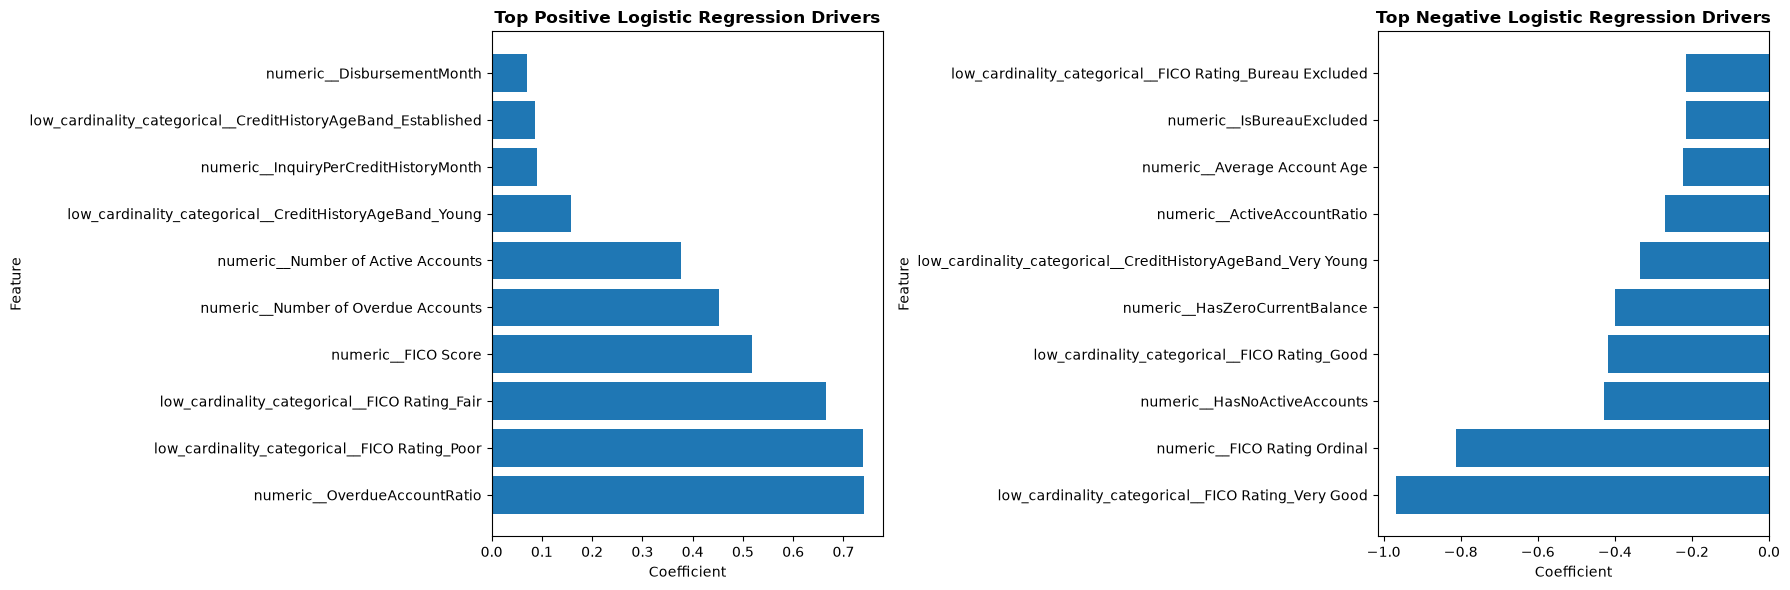

In [18]:
### supervised model - model interpretation - logistic regression - plotting logistic regression drivers
fig, axes = plt.subplots(
    nrows = 1,
    ncols = 2,
    figsize = (18, 6),
    squeeze = False
)

ax_positive = axes[0, 0]
ax_negative = axes[0, 1]

# positive drivers
ax_positive.barh(
    top_positive_logistic_drivers['feature'],
    top_positive_logistic_drivers['coefficient']
)

ax_positive.set_title('Top Positive Logistic Regression Drivers', fontweight = 'bold')
ax_positive.set_xlabel('Coefficient')
ax_positive.set_ylabel('Feature')

# negative drivers
ax_negative.barh(
    top_negative_logistic_drivers['feature'],
    top_negative_logistic_drivers['coefficient']
)

ax_negative.set_title('Top Negative Logistic Regression Drivers', fontweight = 'bold')
ax_negative.set_xlabel('Coefficient')
ax_negative.set_ylabel('Feature')

plt.tight_layout()
plt.show()

In [19]:
### supervised model - model interpretation - native feature importance for tree-based models
# native importances
native_importances = interpreter.get_all_native_feature_importance(
    trained_pipelines = trainer.trained_pipelines_
)

# add business interpretation
native_importances_with_notes = interpreter.add_business_interpretation_notes(
    df = native_importances,
    feature_column = 'feature'
)

display(native_importances_with_notes.head(10))

# save native importances
interpreter.save_interpretation_table(
    df = native_importances_with_notes,
    file_name = 'tree_based_native_feature_importances.csv'
)

,model,feature,importance,business_interpretation
0,decision_tree_depth4,numeric__Legit FICO Scores,0.745448,Credit bureau quality / creditworthiness signal
1,decision_tree_depth4,numeric__OverdueAccountRatio,0.132308,Historical repayment stress / delinquency signal
2,decision_tree_depth4,numeric__Current Balance Amount,0.053654,Outstanding balance / leverage signal
3,decision_tree_depth4,numeric__FICO Score,0.021533,Credit bureau quality / creditworthiness signal
4,decision_tree_depth4,numeric__AccountsPerCreditHistoryMonth,0.020045,Requires manual business review
5,decision_tree_depth4,numeric__Instalment Amount,0.012889,Repayment burden signal
6,decision_tree_depth4,numeric__ActiveAccountRatio,0.010260,Requires manual business review
7,decision_tree_depth4,numeric__RecentlyOpenedAccountRatio,0.002592,Requires manual business review
8,decision_tree_depth4,numeric__Average Account Age,0.000945,Customer maturity / lifecycle signal
9,decision_tree_depth4,numeric__BalanceToDisbursedRatio,0.000329,Outstanding balance / leverage signal


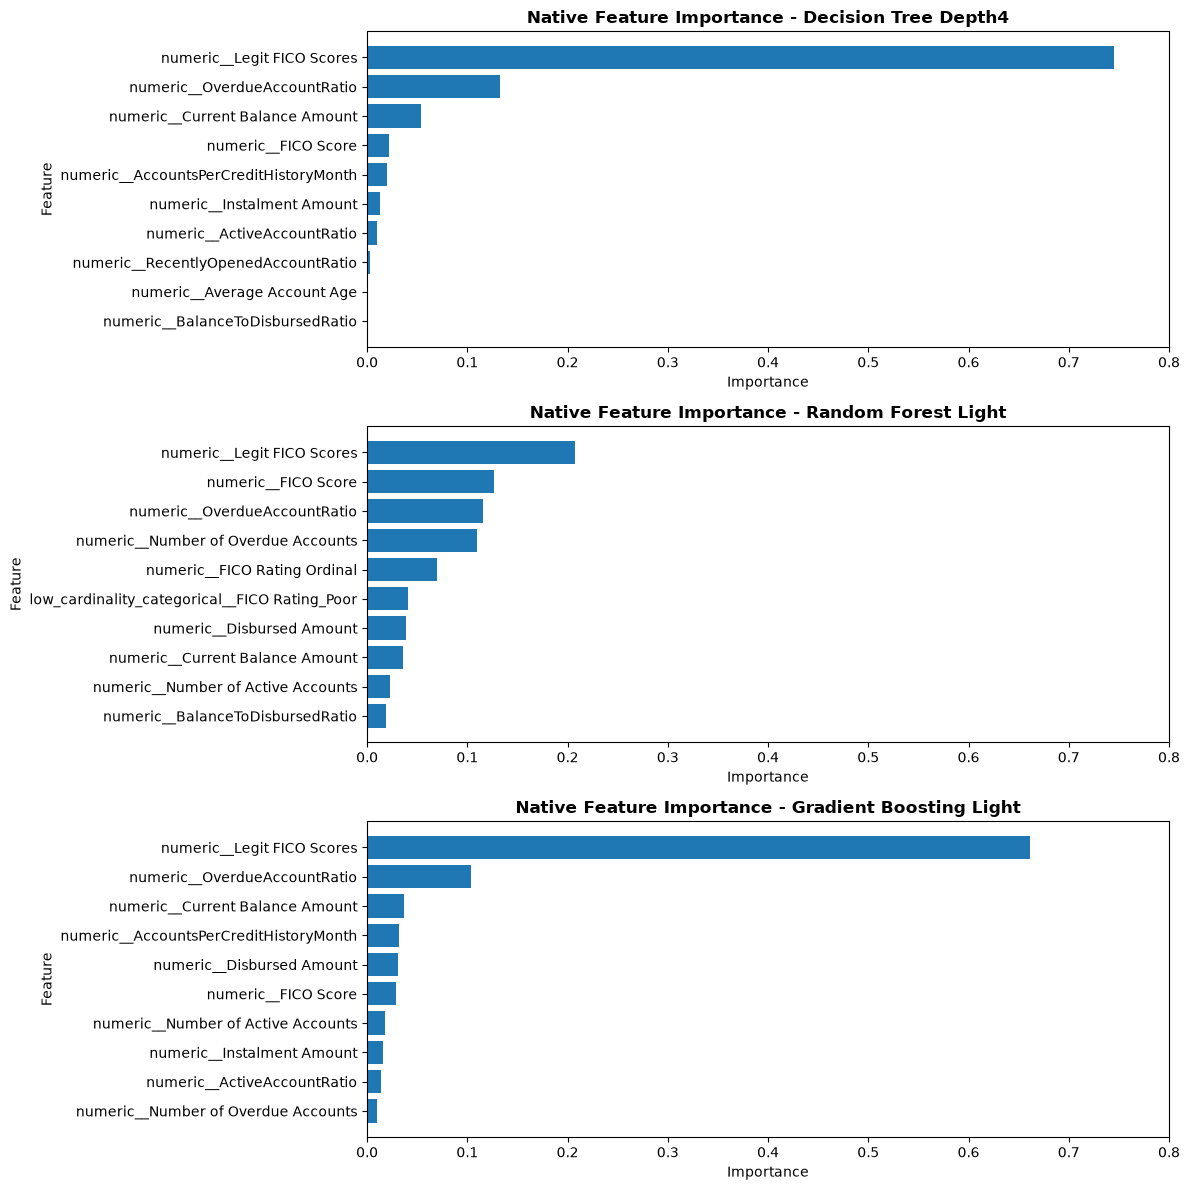

In [20]:
### supervised model - model interpretation - tree_based - plotting native feature importances by model
tree_model_names = (
    native_importances_with_notes['model']
    .unique()
    .tolist()
)

fig, axes = plt.subplots(
    nrows = len(tree_model_names),
    ncols = 1,
    figsize = (12, len(tree_model_names) * 4)
)

axes_flat = axes.flatten()

for ax, model_name in zip(axes_flat, tree_model_names):

    plot_df = (
        native_importances_with_notes
        .query('model == @model_name')
        .sort_values(
            'importance',
            ascending = False
        )
        .head(10)
        .sort_values(
            'importance',
            ascending = True
        )
    )

    ax.barh(
        plot_df['feature'],
        plot_df['importance']
    )

    model_label = model_name.replace("_", " ").title()

    ax.set_title(f'Native Feature Importance - {model_label}', fontweight = 'bold')
    ax.set_xlabel('Importance')
    ax.set_ylabel('Feature')
    ax.set_xlim(0, 0.8)


plt.tight_layout()
plt.show()

In [21]:
### supervised model - model interpretation - permutation importance for all models
# permutation importances
if trainer.X_test_ is None:
    raise ValueError('X_test_ is not available, please fit the trainer first!')
if trainer.y_test_ is None:
    raise ValueError('y_test_ is not available, please fit the trainer first!')

permutation_importances = interpreter.get_all_permutation_importances(
    trained_pipelines = trainer.trained_pipelines_,
    X = trainer.X_test_,
    y = trainer.y_test_,
    scoring = 'average_precision',
    n_repeats = 5,
    n_jobs = -1
)

# add business interpretation
permutation_importances_with_notes = interpreter.add_business_interpretation_notes(
    df = permutation_importances,
    feature_column = 'feature'
)

display(permutation_importances_with_notes.head(10))

# save permutation importances
interpreter.save_interpretation_table(
    df = permutation_importances_with_notes,
    file_name = 'permutation_feature_importances.csv'
)

,model,feature,importance_mean,importance_std,scoring,business_interpretation
0,logistic_regression_baseline,FICO Rating,0.086268,0.002125,average_precision,Credit bureau quality / creditworthiness signal
1,logistic_regression_baseline,Number of Active Accounts,0.080326,0.004328,average_precision,Requires manual business review
2,logistic_regression_baseline,Number of Overdue Accounts,0.049127,0.003267,average_precision,Historical repayment stress / delinquency signal
3,logistic_regression_baseline,FICO Score,0.044132,0.002366,average_precision,Credit bureau quality / creditworthiness signal
4,logistic_regression_baseline,FICO Rating Ordinal,0.034089,0.003606,average_precision,Credit bureau quality / creditworthiness signal
5,logistic_regression_baseline,Average Account Age,0.024924,0.001369,average_precision,Customer maturity / lifecycle signal
6,logistic_regression_baseline,OverdueAccountRatio,0.011337,0.001658,average_precision,Historical repayment stress / delinquency signal
7,logistic_regression_baseline,HasZeroCurrentBalance,0.009556,0.002069,average_precision,Outstanding balance / leverage signal
8,logistic_regression_baseline,Number of Accounts Opened Last 6 Months,0.009134,0.002070,average_precision,Requires manual business review
9,logistic_regression_baseline,HasNoActiveAccounts,0.008045,0.001789,average_precision,Requires manual business review


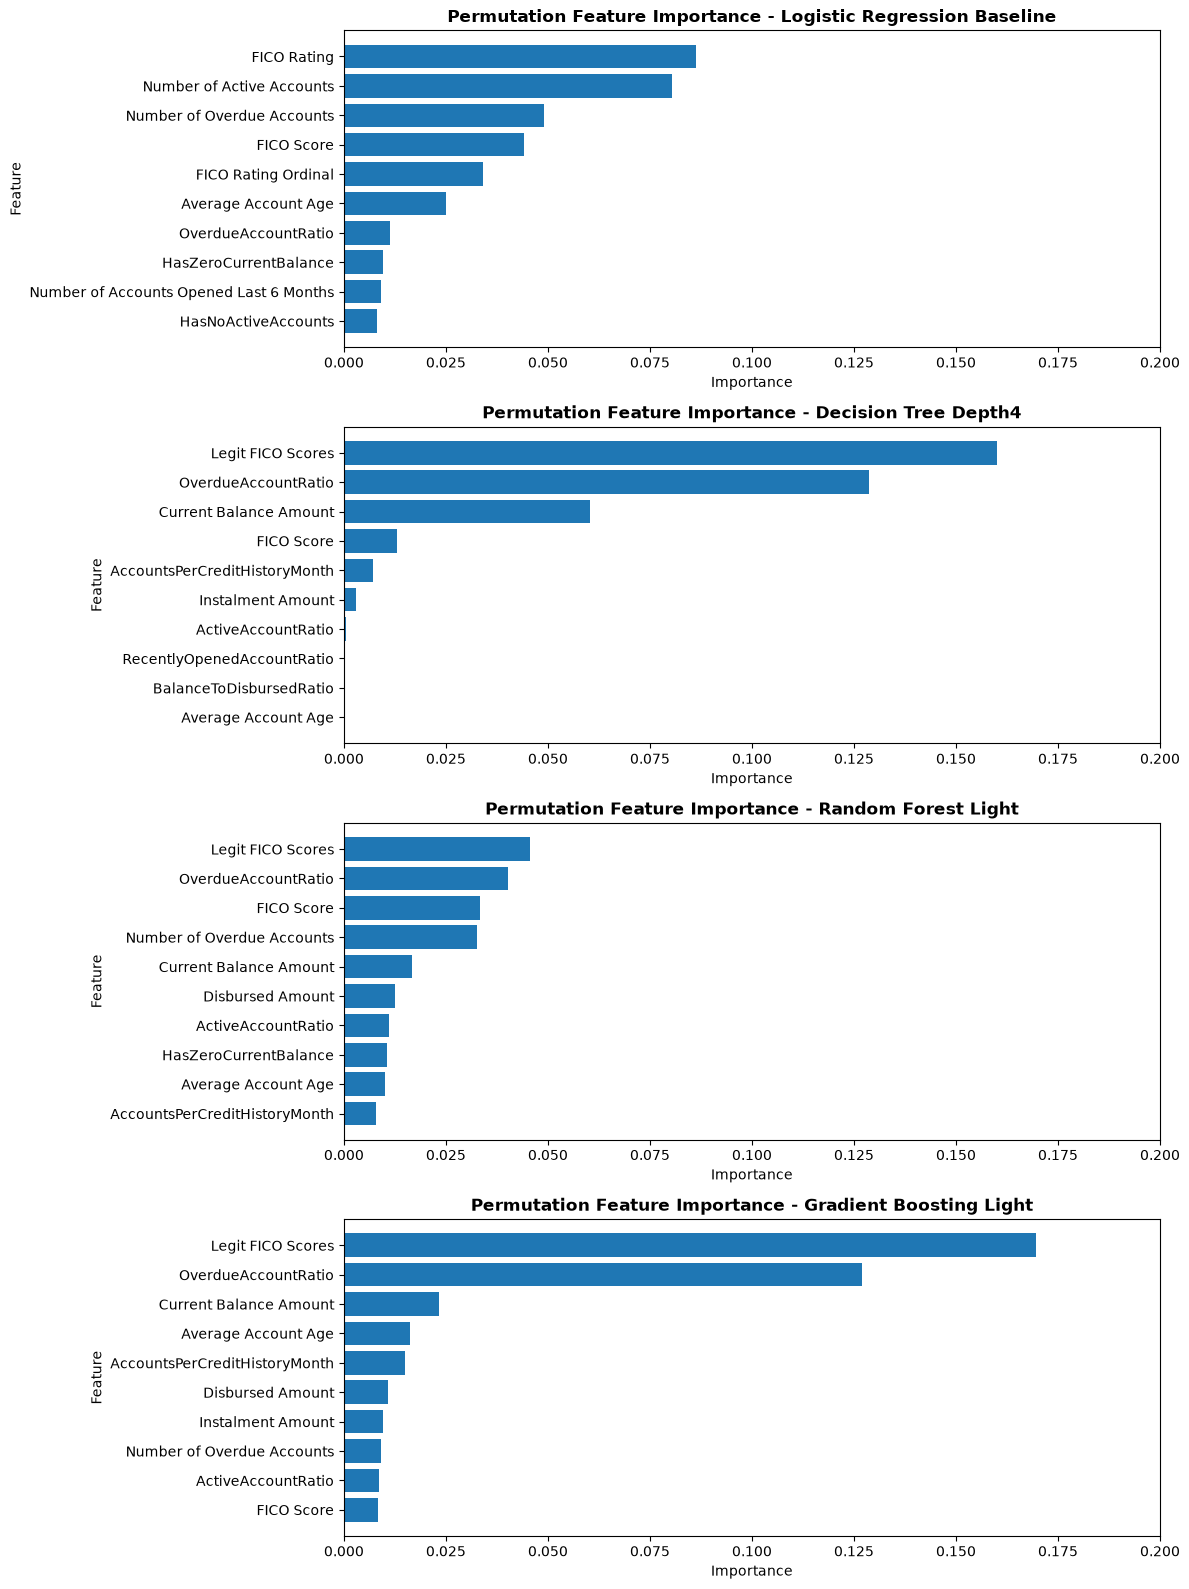

In [22]:
### supervised model - model interpretation - tree_based - plotting permutation feature importances by model
all_model_names = (
    permutation_importances_with_notes['model']
    .unique()
    .tolist()
)

fig, axes = plt.subplots(
    nrows = len(all_model_names),
    ncols = 1,
    figsize = (12, len(all_model_names) * 4)
)

axes_flat = axes.flatten()

for ax, model_name in zip(axes_flat, all_model_names):

    plot_df = (
        permutation_importances_with_notes
        .query('model == @model_name')
        .sort_values(
            'importance_mean',
            ascending = False
        )
        .head(10)
        .sort_values(
            'importance_mean',
            ascending = True
        )
    )

    ax.barh(
        plot_df['feature'],
        plot_df['importance_mean']
    )

    model_label = model_name.replace("_", " ").title()

    ax.set_title(f'Permutation Feature Importance - {model_label}', fontweight = 'bold')
    ax.set_xlabel('Importance')
    ax.set_ylabel('Feature')
    ax.set_xlim(0, 0.2)

plt.tight_layout()
plt.show()

In [23]:
### supervised model - model interpretation - business interpretation summary table
top_permutation_summary = (
    permutation_importances_with_notes
    .sort_values(
        by = [
            'model', 
            'importance_mean'
        ],
        ascending = [
            True,
            False
        ]
    )
    .groupby('model')
    .head(7)
    .reset_index(drop = True)
    .loc[:, [
        'model',
        'feature',
        'importance_mean',
        'importance_std',
        'business_interpretation'
    ]]
)

top_permutation_summary

,model,feature,importance_mean,importance_std,business_interpretation
0,decision_tree_depth4,Legit FICO Scores,0.160066,0.004213,Credit bureau quality / creditworthiness signal
1,decision_tree_depth4,OverdueAccountRatio,0.128690,0.000981,Historical repayment stress / delinquency signal
2,decision_tree_depth4,Current Balance Amount,0.060259,0.004543,Outstanding balance / leverage signal
3,decision_tree_depth4,FICO Score,0.013101,0.000747,Credit bureau quality / creditworthiness signal
4,decision_tree_depth4,AccountsPerCreditHistoryMonth,0.007150,0.000797,Requires manual business review
5,decision_tree_depth4,Instalment Amount,0.002931,0.000328,Repayment burden signal
6,decision_tree_depth4,ActiveAccountRatio,0.000567,0.000137,Requires manual business review
7,gradient_boosting_light,Legit FICO Scores,0.169678,0.008949,Credit bureau quality / creditworthiness signal
8,gradient_boosting_light,OverdueAccountRatio,0.126884,0.006207,Historical repayment stress / delinquency signal
9,gradient_boosting_light,Current Balance Amount,0.023384,0.003926,Outstanding balance / leverage signal


* across the models listed in summary table, features related to credit bureau quality, repayment stress / burden signal, exposure size, outstanding balance and customer maturity should be reviewed carefully, since they have direct financial meaning

#### **Threshold Tuning**

The threshold tuning reflect business cost in default-risk classification problem where the default threshold of 0.5 may not be optimal considering the precision-recall trade-off curve 
and relevant business decision policy depending on the investigation capacity

In [24]:
### supervised model - threshold tuning - threshold results for all candidate threshold values over all trained model pipelines
# initialize threshold tuner class object
threshold_tuner = ThresholdTuner(
    thresholds = np.arange(0.05, 0.96, 0.05)
)

# evaluate all fitterd model pipelines across all candidate threshold values
if trainer.X_test_ is None:
    raise ValueError('X_test_ is not available, please fit the trainer first!')
if trainer.y_test_ is None:
    raise ValueError('y_test_ is not available, please fit the trainer first!')

threshold_results = threshold_tuner.tune_all_models(
    trained_pipelines = trainer.trained_pipelines_,
    X_test = trainer.X_test_,
    y_test = trainer.y_test_
)

display(threshold_results.head())

# save threshold tuning results into metrics directory
threshold_tuner.save_threshold_results(
    threshold_results = threshold_results,
    file_name = 'threshold_tuning_results.csv'
)

,threshold,accuracy,balanced_accuracy,precision,recall,f1_score,true_positive,true_negative,false_positive,false_negative,predicted_positive_rate,model
0,0.05,0.156536,0.502892,0.151986,0.999444,0.263849,1798,64,10032,1,0.994536,logistic_regression_baseline
1,0.10,0.205969,0.529271,0.159208,0.992774,0.274410,1786,664,9432,13,0.943085,logistic_regression_baseline
2,0.15,0.357881,0.610768,0.187453,0.973319,0.314363,1751,2506,7590,48,0.785288,logistic_regression_baseline
3,0.20,0.465826,0.660881,0.213125,0.940523,0.347505,1692,3849,6247,107,0.667423,logistic_regression_baseline
4,0.25,0.548886,0.700675,0.240431,0.918288,0.381084,1652,4877,5219,147,0.577638,logistic_regression_baseline


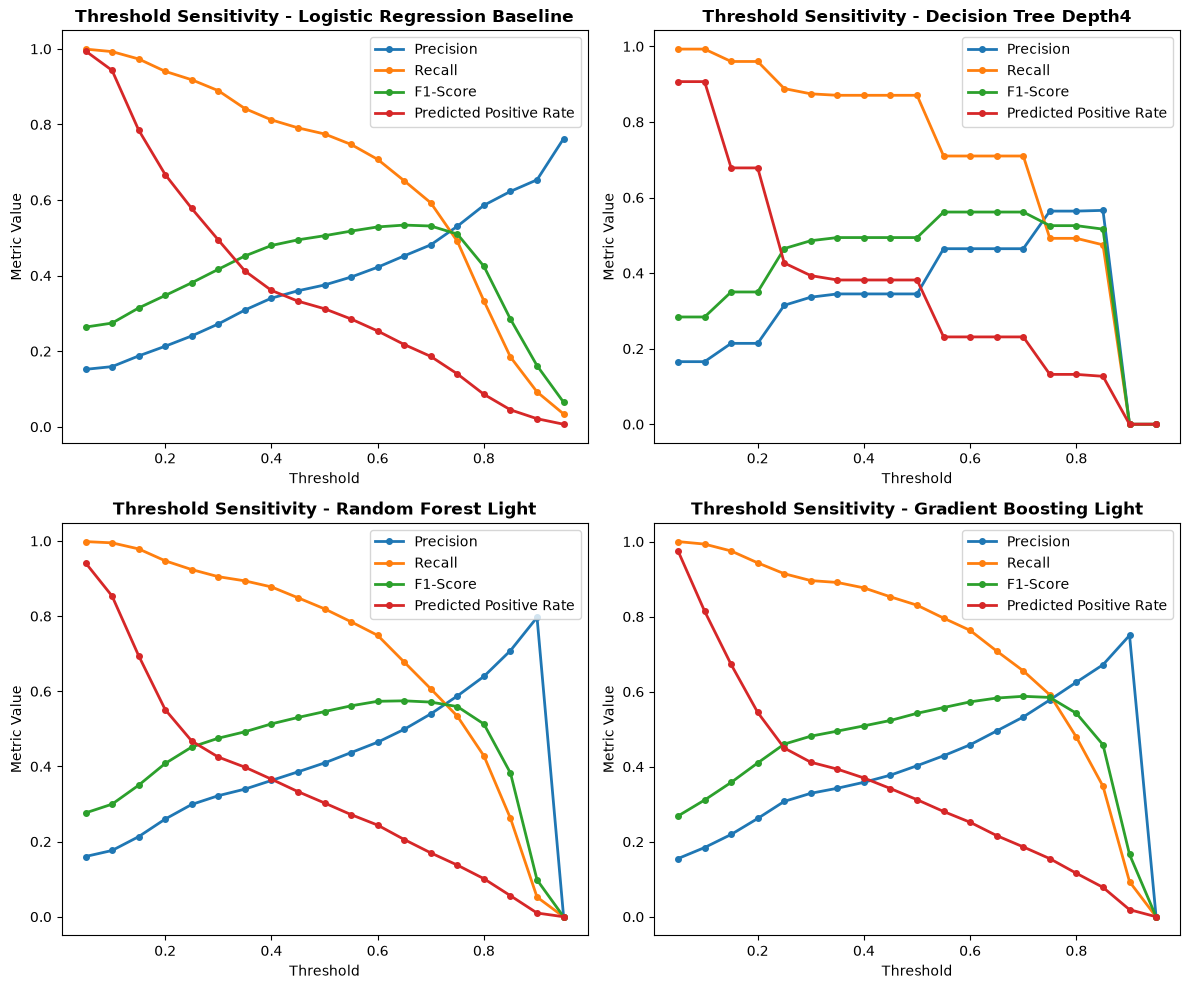

In [25]:
### supervised model - threshold tuning - plot threshold sensitivity
all_model_names = (
    threshold_results['model']
    .unique()
    .tolist()
)

n_models = len(all_model_names)
n_cols = 2
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(
    nrows = n_rows,
    ncols = n_cols,
    figsize = (6 * n_cols, 5 * n_rows),
    squeeze = False
)

axes = axes.flatten()

for ax, model_name in zip(axes, all_model_names):

    plot_df = (
        threshold_results
        .query('model == @model_name')
    )

    ax.plot(
        plot_df['threshold'],
        plot_df['precision'],
        marker = 'o',
        markersize = 4,
        linewidth = 2,
        label = 'Precision'
    )

    ax.plot(
        plot_df['threshold'],
        plot_df['recall'],
        marker = 'o',
        markersize = 4,
        linewidth = 2,
        label = 'Recall'
    )

    ax.plot(
        plot_df['threshold'],
        plot_df['f1_score'],
        marker = 'o',
        markersize = 4,
        linewidth = 2,
        label = 'F1-Score'
    )

    ax.plot(
        plot_df['threshold'],
        plot_df['predicted_positive_rate'],
        marker = 'o',
        markersize = 4,
        linewidth = 2,
        label = 'Predicted Positive Rate'
    )

    model_label = model_name.replace('_', ' ').title()

    ax.set_title(
        f'Threshold Sensitivity - {model_label}',
        fontweight = 'bold'
    )
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Metric Value')
    ax.legend()

plt.tight_layout()
plt.show()

In [26]:
### supervised model - threshold tuning - selecting threshold using business selection strategies
# maximizing f1-score
best_thresholds_max_f1 = threshold_tuner.select_best_thresholds_for_all_models(
    threshold_results = threshold_results,
    selection_strategy = 'max_f1'
)
print('--- Threshold Selection by Maximizing F1-Score ---')
display(best_thresholds_max_f1)

# maximizing precision, while keeping minimum recall over 0.70
best_thresholds_max_precision_min_recall_over_70 = threshold_tuner.select_best_thresholds_for_all_models(
    threshold_results = threshold_results,
    selection_strategy = 'max_precision',
    min_recall = 0.70
)
print('--- Threshold Selection by Maximizing Precision While Keeping Recall Over 70% ---')
display(best_thresholds_max_precision_min_recall_over_70)

# save threshold tuning results into metrics directory
best_thresholds_max_f1.to_csv(
    METRICS_DIR / 'best_thresholds_max_f1.csv',
    index = False
)

best_thresholds_max_precision_min_recall_over_70.to_csv(
    METRICS_DIR / 'best_thresholds_max_precision_min_recall_over_70.csv',
    index = False
)

--- Threshold Selection by Maximizing F1-Score ---


,threshold,accuracy,balanced_accuracy,precision,recall,f1_score,true_positive,true_negative,false_positive,false_negative,predicted_positive_rate,model
0,0.70,0.860866,0.776424,0.532520,0.655364,0.587590,1179,9061,1035,620,0.186129,gradient_boosting_light
1,0.65,0.848256,0.778132,0.498773,0.677599,0.574593,1219,8871,1225,580,0.205464,random_forest_light
2,0.55,0.832367,0.782019,0.464533,0.709839,0.561566,1277,8624,1472,522,0.231106,decision_tree_depth4
3,0.65,0.827995,0.755233,0.452298,0.650917,0.533728,1171,8678,1418,628,0.217654,logistic_regression_baseline


--- Threshold Selection by Maximizing Precision While Keeping Recall Over 70% ---


,threshold,accuracy,balanced_accuracy,precision,recall,f1_score,true_positive,true_negative,false_positive,false_negative,predicted_positive_rate,model
0,0.65,0.846742,0.789803,0.495334,0.708171,0.582933,1274,8798,1298,525,0.216225,gradient_boosting_light
1,0.60,0.831442,0.797463,0.464483,0.748749,0.573313,1347,8543,1553,452,0.243800,random_forest_light
2,0.55,0.832367,0.782019,0.464533,0.709839,0.561566,1277,8624,1472,522,0.231106,decision_tree_depth4
3,0.60,0.809332,0.767536,0.422222,0.707615,0.528874,1273,8354,1742,526,0.253468,logistic_regression_baseline
